# SECOM EDA

Goal: characterize the raw SECOM wafer data and select preprocessing settings for `configs/config.yaml`. This notebook examines target imbalance, missingness, low-variance sensors, sensor redundancy, and temporal structure before finalizing the pipeline configuration.

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from yield_risk.data import load_secom
from yield_risk.validation import validate_secom

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
RAW_DIR = Path("../data/raw")

df = load_secom(RAW_DIR)
validate_secom(df)

print(f"Shape : {df.shape}")
df.head()

Shape : (1567, 592)


,sensor_000,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,0,"""19/07/2008 11:55:00"""
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,0,"""19/07/2008 12:32:00"""
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,"""19/07/2008 13:17:00"""
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,0,"""19/07/2008 14:43:00"""
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,0,"""19/07/2008 15:22:00"""


## 1  Class balance

**Question:** What is the pass/fail distribution, and how imbalanced is the target variable?

label
pass    1463
fail     104
Name: count, dtype: int64

Fail rate: 6.6%


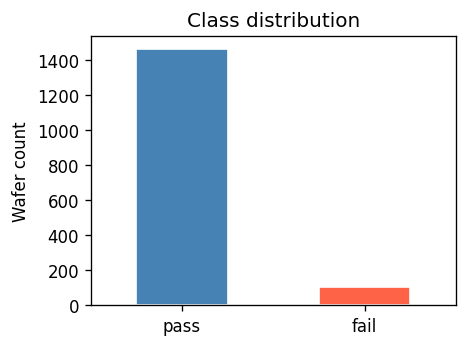

In [3]:
counts = df["label"].value_counts().rename({0: "pass", 1: "fail"})
print(counts)
print(f"\nFail rate: {counts['fail'] / counts.sum():.1%}")

fig, ax = plt.subplots(figsize=(4, 3))
counts.plot.bar(ax=ax, color=["steelblue", "tomato"], edgecolor="white")
ax.set_title("Class distribution")
ax.set_xlabel("")
ax.set_ylabel("Wafer count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

Failures make up only **6.6%** of wafers, indicating a clear class imbalance. This should be handled during modeling with stratified splits, imbalance-aware metrics, and possibly class weighting.

## 2  Missing values

**Question:** How are missing values distributed across features, and are there features with unusually high missingness?

In [4]:
sensor_cols = [c for c in df.columns if c not in {"label", "timestamp"}]
missing_rate = df[sensor_cols].isnull().mean().sort_values(ascending=False)

for t in [0.50, 0.60, 0.80, 1.00]:
    n = (missing_rate > t).sum() if t < 1.0 else (missing_rate == 1.0).sum()
    op = ">" if t < 1.0 else "=="
    print(f"Sensors with missing rate {op} {t:.0%}: {n}")

Sensors with missing rate > 50%: 28
Sensors with missing rate > 60%: 24
Sensors with missing rate > 80%: 8
Sensors with missing rate == 100%: 0


A substantial group of sensors has high missingness: **28 sensors exceed 50% missing values**, **24 exceed 60%**, and **8 exceed 80%**, while no sensor is completely missing. A `missing_threshold = 0.60` is therefore a reasonable initial cutoff, but the 50–60% range should be reviewed because several sensors sit near the boundary.

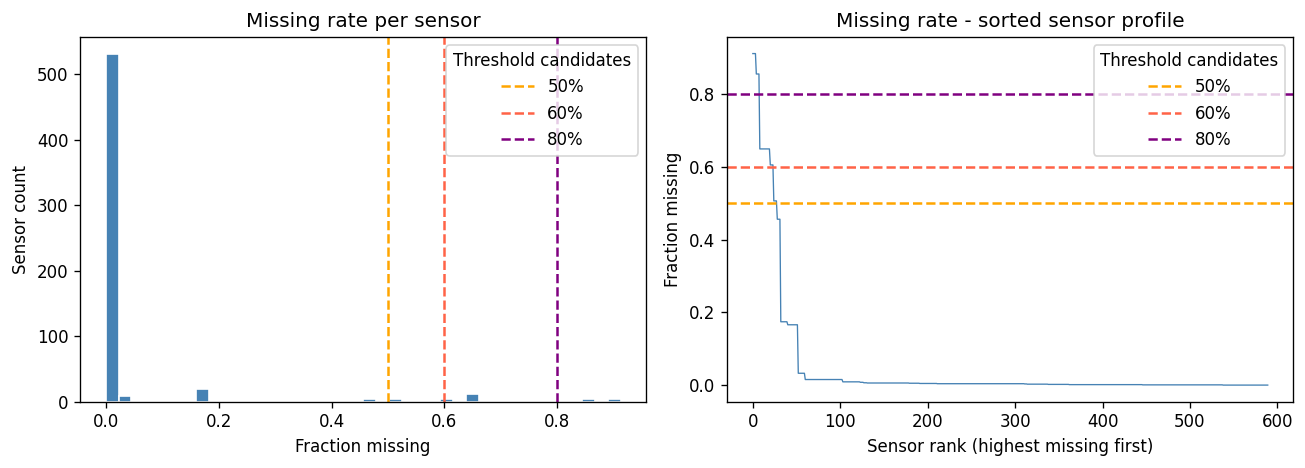

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(missing_rate.values, bins=40, color="steelblue", edgecolor="white")
for thresh, color in [(0.50, "orange"), (0.60, "tomato"), (0.80, "purple")]:
    axes[0].axvline(thresh, color=color, linestyle="--", label=f"{thresh:.0%}")
axes[0].set_title("Missing rate per sensor")
axes[0].set_xlabel("Fraction missing")
axes[0].set_ylabel("Sensor count")
axes[0].legend(title="Threshold candidates")

axes[1].plot(missing_rate.values, color="steelblue", linewidth=0.8)
for thresh, color in [(0.50, "orange"), (0.60, "tomato"), (0.80, "purple")]:
    axes[1].axhline(thresh, color=color, linestyle="--", label=f"{thresh:.0%}")
axes[1].set_title("Missing rate - sorted sensor profile")
axes[1].set_xlabel("Sensor rank (highest missing first)")
axes[1].set_ylabel("Fraction missing")
axes[1].legend(title="Threshold candidates")

plt.tight_layout()

Most sensors have little or no missingness, but a small subset has very high missing rates. The sharp drop in the sorted missingness profile supports using `missing_threshold = 0.60` as an initial cutoff, with the 50–60% sensors reviewed separately before removal.

In [6]:
sensor_cols_missing_ok = missing_rate[missing_rate <= 0.60].index.tolist()

print(f"Original sensors: {len(sensor_cols)}")
print(f"After missingness filter: {len(sensor_cols_missing_ok)}")
print(f"Dropped for missingness: {len(sensor_cols) - len(sensor_cols_missing_ok)}")

Original sensors: 590
After missingness filter: 566
Dropped for missingness: 24


## 3  Variance

**Question:** Among sensors that pass the missingness filter, how many are constant or near-constant after median imputation?

In [7]:
df_imputed = df[sensor_cols_missing_ok].fillna(df[sensor_cols_missing_ok].median())
variances = df_imputed.var().sort_values()

print(f"Sensors with variance == 0   : {(variances == 0).sum()}")
print(f"Sensors with variance < 0.01 : {(variances < 0.01).sum()}")
print(f"Sensors with variance < 0.10 : {(variances < 0.10).sum()}")
print()
print(variances.describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]))

Sensors with variance == 0   : 116
Sensors with variance < 0.01 : 265
Sensors with variance < 0.10 : 307

count    5.660000e+02
mean     1.592687e+05
std      2.038679e+06
min      0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
25%      8.932312e-06
50%      3.081529e-02
75%      4.104429e+01
90%      1.444918e+03
95%      6.017444e+04
max      4.290600e+07
dtype: float64


After removing sensors with more than 60% missingness, **566 sensors remain**. Of these, **116 are constant** and should be removed; using `variance_threshold = 0.01` would remove **265 sensors total**, indicating a large group of near-constant features among the retained sensors.

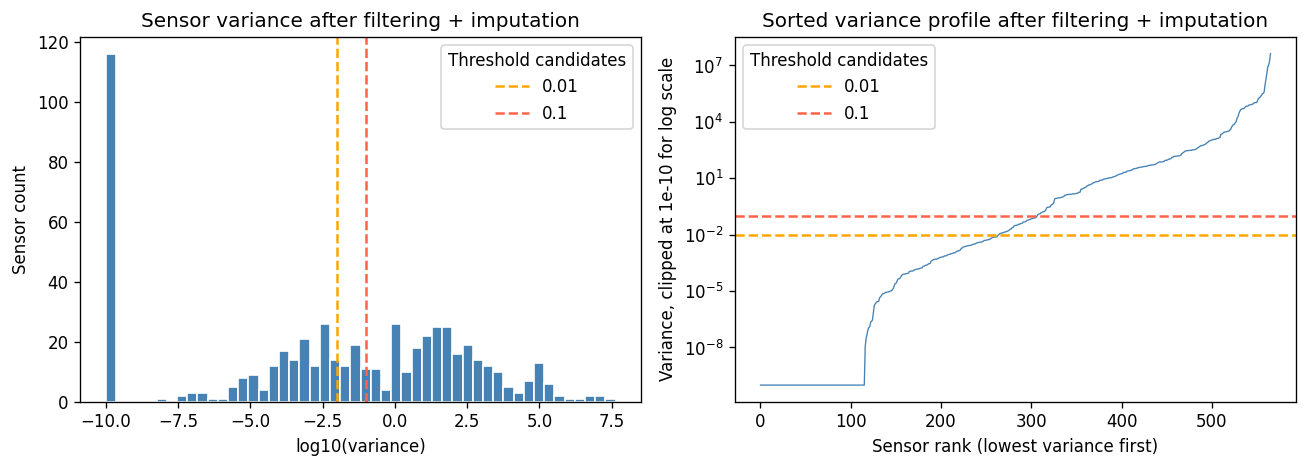

In [8]:
plot_variances = variances.clip(lower=1e-10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

log_var = np.log10(plot_variances.values)

axes[0].hist(log_var, bins=50, color="steelblue", edgecolor="white")
for thresh, color in [(0.01, "orange"), (0.10, "tomato")]:
    axes[0].axvline(np.log10(thresh), color=color, linestyle="--", label=str(thresh))

axes[0].set_title("Sensor variance after filtering + imputation")
axes[0].set_xlabel("log10(variance)")
axes[0].set_ylabel("Sensor count")
axes[0].legend(title="Threshold candidates")

axes[1].semilogy(plot_variances.values, color="steelblue", linewidth=0.8)
for thresh, color in [(0.01, "orange"), (0.10, "tomato")]:
    axes[1].axhline(thresh, color=color, linestyle="--", label=str(thresh))

axes[1].set_title("Sorted variance profile after filtering + imputation")
axes[1].set_xlabel("Sensor rank (lowest variance first)")
axes[1].set_ylabel("Variance, clipped at 1e-10 for log scale")
axes[1].legend(title="Threshold candidates")

plt.tight_layout()

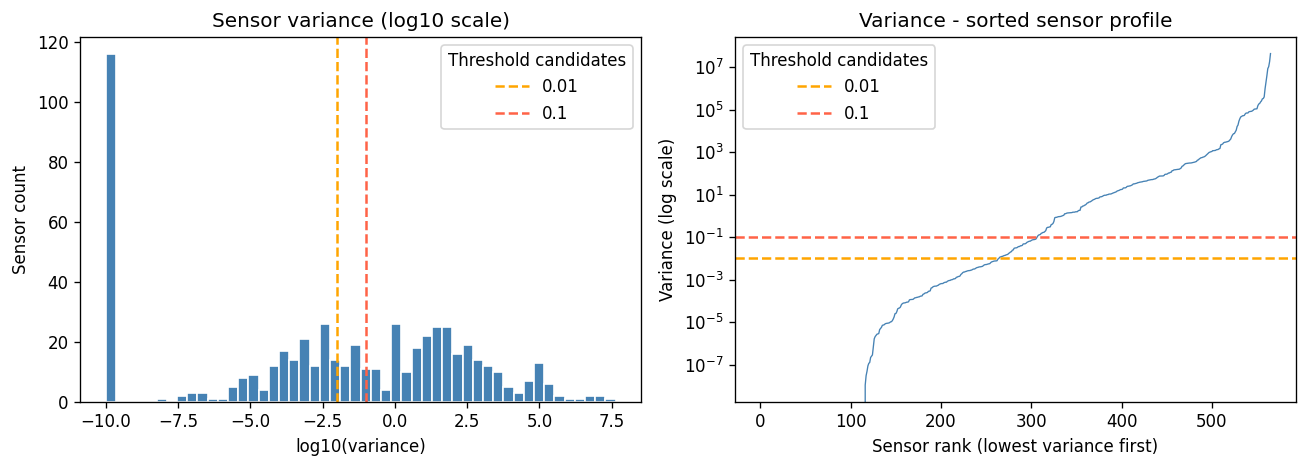

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

log_var = np.log10(variances.clip(lower=1e-10).values)
axes[0].hist(log_var, bins=50, color="steelblue", edgecolor="white")
for thresh, color in [(0.01, "orange"), (0.10, "tomato")]:
    axes[0].axvline(np.log10(thresh), color=color, linestyle="--", label=str(thresh))
axes[0].set_title("Sensor variance (log10 scale)")
axes[0].set_xlabel("log10(variance)")
axes[0].set_ylabel("Sensor count")
axes[0].legend(title="Threshold candidates")

axes[1].semilogy(variances.values, color="steelblue", linewidth=0.8)
for thresh, color in [(0.01, "orange"), (0.10, "tomato")]:
    axes[1].axhline(thresh, color=color, linestyle="--", label=str(thresh))
axes[1].set_title("Variance - sorted sensor profile")
axes[1].set_xlabel("Sensor rank (lowest variance first)")
axes[1].set_ylabel("Variance (log scale)")
axes[1].legend(title="Threshold candidates")

plt.tight_layout()

The variance plots show a large group of constant or near-constant sensors after missingness filtering and median imputation. The spike at very low variance corresponds mostly to sensors with zero variance, while `variance_threshold = 0.01` removes a broader low-variance group: **265 of 566 retained sensors**. This threshold is reasonable as a first-pass filter, but because variance is scale-dependent, the final cutoff should be validated during modeling.

## 4  Correlation

**Question:** After missingness and variance filtering, how much redundancy remains among sensors, and how sensitive is feature removal to the correlation cutoff?

In [10]:
from yield_risk.preprocess import drop_high_missing, drop_low_variance, impute_median

df_clean = drop_high_missing(df, threshold=0.60)
df_clean = impute_median(df_clean)
df_clean = drop_low_variance(df_clean, threshold=0.01)

clean_sensors = [c for c in df_clean.columns if c not in {"label", "timestamp"}]
print(f"Sensors remaining after missing + variance drop: {len(clean_sensors)}")

corr = df_clean[clean_sensors].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))

print()
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n_pairs = int((upper > thresh).sum().sum())
    n_drop  = len([c for c in upper.columns if bool((upper[c] > thresh).any())])
    print(f"  |r| > {thresh:.2f}:  {n_pairs:4d} pairs  ->  would drop {n_drop} sensors")

Sensors remaining after missing + variance drop: 301

  |r| > 0.80:   428 pairs  ->  would drop 142 sensors
  |r| > 0.90:   220 pairs  ->  would drop 119 sensors
  |r| > 0.95:   160 pairs  ->  would drop 103 sensors
  |r| > 0.99:    74 pairs  ->  would drop 59 sensors


After missingness and variance filtering, **301 sensors remain**, but many are still highly redundant. A correlation threshold of `0.95` identifies **160 highly correlated pairs** and would remove **103 sensors**, which is a substantial but manageable reduction. Because even `0.99` would remove **59 sensors**, strong sensor redundancy is present regardless of the exact threshold.

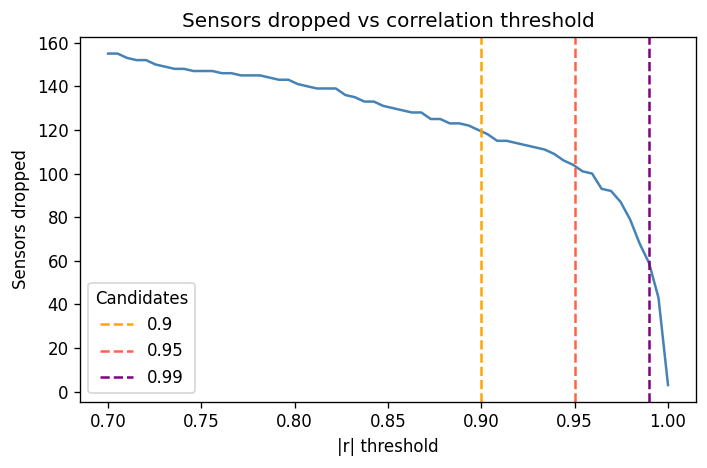

In [11]:
thresholds = np.linspace(0.70, 1.00, 60)
n_dropped = [
    len([c for c in upper.columns if bool((upper[c] > t).any())])
    for t in thresholds
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, n_dropped, color="steelblue")
for thresh, color in [(0.90, "orange"), (0.95, "tomato"), (0.99, "purple")]:
    ax.axvline(thresh, color=color, linestyle="--", label=str(thresh))
ax.set_title("Sensors dropped vs correlation threshold")
ax.set_xlabel("|r| threshold")
ax.set_ylabel("Sensors dropped")
ax.legend(title="Candidates")
plt.tight_layout()

The correlation sensitivity plot shows that many retained sensors are redundant after missingness and variance filtering. A threshold of `|r| > 0.95` would remove about **103 sensors**, which is less aggressive than `0.90` but still removes substantially more redundancy than `0.99`. This supports `correlation_threshold = 0.95` as a reasonable first-pass cutoff for reducing highly correlated sensor features.

## 5  Feature count through the full pipeline

How many sensors survive at the current config values?

In [12]:
from yield_risk.preprocess import (
    drop_high_missing,
    impute_median,
    drop_low_variance,
    drop_high_correlation,
)

NON_SENSOR = {"label", "timestamp"}

def n_sensors(d: pd.DataFrame) -> int:
    return len([c for c in d.columns if c not in NON_SENSOR])

MISSING_THRESH  = 0.60
VARIANCE_THRESH = 0.01
CORR_THRESH     = 0.95

s0 = df.copy()
s1 = drop_high_missing(s0,   MISSING_THRESH)
s2 = impute_median(s1)
s3 = drop_low_variance(s2,   VARIANCE_THRESH)
s4 = drop_high_correlation(s3, CORR_THRESH)

print(f"Raw                 : {n_sensors(s0):4d} sensors")
print(f"After missing drop  : {n_sensors(s1):4d} sensors  (dropped {n_sensors(s0) - n_sensors(s1)})")
print(f"After imputation    : {n_sensors(s2):4d} sensors")
print(f"After var drop      : {n_sensors(s3):4d} sensors  (dropped {n_sensors(s2) - n_sensors(s3)})")
print(f"After corr drop     : {n_sensors(s4):4d} sensors  (dropped {n_sensors(s3) - n_sensors(s4)})")

Raw                 :  590 sensors
After missing drop  :  566 sensors  (dropped 24)
After imputation    :  566 sensors
After var drop      :  301 sensors  (dropped 265)
After corr drop     :  198 sensors  (dropped 103)


Using the current preprocessing settings, the sensor set is reduced from **590 raw sensors** to **198 retained sensors**. The missingness filter removes **24 sensors**, median imputation preserves the feature count, the variance filter removes **265 near-constant sensors**, and the correlation filter removes **103 redundant sensors**.

## 6  Temporal distribution

Are failures clustered in time or spread evenly?
Matters for whether a random split is appropriate.

Unparsed timestamps: 0


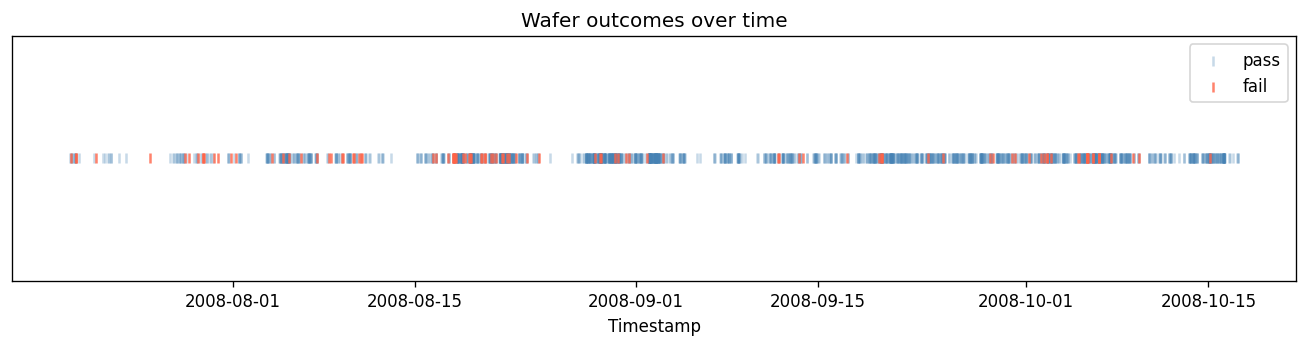

In [13]:
ts_raw = df["timestamp"].astype(str).str.strip('"')

ts = pd.to_datetime(
    ts_raw,
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

bad_ts = ts.isna().sum()
print(f"Unparsed timestamps: {bad_ts}")

plot_df = (
    df.assign(timestamp_parsed=ts)
      .dropna(subset=["timestamp_parsed"])
      .sort_values("timestamp_parsed")
)

fail_mask = plot_df["label"].eq(1)

fig, ax = plt.subplots(figsize=(11, 3))

ax.scatter(
    plot_df.loc[~fail_mask, "timestamp_parsed"],
    np.zeros((~fail_mask).sum()),
    marker="|",
    alpha=0.3,
    color="steelblue",
    label="pass",
)

ax.scatter(
    plot_df.loc[fail_mask, "timestamp_parsed"],
    np.zeros(fail_mask.sum()),
    marker="|",
    alpha=0.8,
    color="tomato",
    label="fail",
)

ax.set_title("Wafer outcomes over time")
ax.set_xlabel("Timestamp")
ax.set_yticks([])
ax.legend()

plt.tight_layout()

In [14]:
weekly = (
    plot_df
    .set_index("timestamp_parsed")
    .resample("W")["label"]
    .agg(total="count", fails="sum")
)

weekly["fail_rate"] = weekly["fails"] / weekly["total"]

print(weekly)

                  total  fails  fail_rate
timestamp_parsed                         
2008-07-20           13      3   0.230769
2008-07-27           21      2   0.095238
2008-08-03           48     10   0.208333
2008-08-10          108     14   0.129630
2008-08-17           51      7   0.137255
2008-08-24          208     22   0.105769
2008-08-31          169      7   0.041420
2008-09-07          133      2   0.015038
2008-09-14           95      4   0.042105
2008-09-21          154      5   0.032468
2008-09-28          166      4   0.024096
2008-10-05          169     15   0.088757
2008-10-12          138      8   0.057971
2008-10-19           94      1   0.010638


Failures occur throughout the dataset, but the weekly failure-rate summary shows clear temporal variation. Failure rates are highest in the early period, especially late July through August, drop substantially through September, and show a smaller increase in early October. This suggests possible temporal drift, so a stratified random split is acceptable for an initial baseline, but a time-based validation split should also be tested.

---

## EDA conclusions

| Setting                  | Observation                                                                                                                                  | Selected value                                                      |
| ------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------- |
| `missing_threshold`      | 24 of 590 sensors have more than 60% missingness. Most sensors have little or no missing data, while a smaller group has high missingness.   | `0.60`                                                              |
| `variance_threshold`     | After missingness filtering and median imputation, 116 sensors are constant and 265 of 566 retained sensors have variance below 0.01.        | `0.01`                                                              |
| `correlation_threshold`  | After missingness and variance filtering, 301 sensors remain. A `\|r\| > 0.95` threshold removes 103 redundant sensors, leaving 198 sensors. | `0.95`                                                              |
| Class imbalance handling | Failures represent 104 of 1,567 wafers, or 6.6% of the dataset.                                                                              | Stratified split + class-weighted baseline                          |
| Validation strategy      | Failures occur throughout the time range but are more frequent early in the dataset.                                                         | Stratified random split first; time-based split as robustness check |
